<a href="https://colab.research.google.com/github/Aman1477r/ML-journey/blob/main/Task1_%26_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

#### First i import the dataset and read

In [ ]:
df = pd.read_csv('data_labels.csv')

In [ ]:

df.head()

,id,path,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage
0,15970,/kaggle/input/fashion-product-images-small/ima...,1,1,1,1,1,1,1,1
1,39386,/kaggle/input/fashion-product-images-small/ima...,1,1,2,2,2,2,2,1
2,59263,/kaggle/input/fashion-product-images-small/ima...,2,2,3,3,3,3,3,1
3,21379,/kaggle/input/fashion-product-images-small/ima...,1,1,2,4,4,1,1,1
4,53759,/kaggle/input/fashion-product-images-small/ima...,1,1,1,5,5,2,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44072 entries, 0 to 44071
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              44072 non-null  int64 
 1   path            44072 non-null  object
 2   gender          44072 non-null  int64 
 3   masterCategory  44072 non-null  int64 
 4   subCategory     44072 non-null  int64 
 5   articleType     44072 non-null  int64 
 6   baseColour      44072 non-null  int64 
 7   season          44072 non-null  int64 
 8   year            44072 non-null  int64 
 9   usage           44072 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 3.4+ MB


In [ ]:
 df.describe()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage
count,44072.000000,44072.000000,44072.000000,44072.000000,44072.000000,44072.000000,44072.000000,44072.000000,44072.000000
mean,29550.072972,1.691732,1.830595,6.252814,20.956253,8.859639,2.057111,2.493692,1.464898
std,16974.738560,0.958629,0.943350,6.822976,22.549882,7.631119,0.833584,1.766922,0.975218
min,1163.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,14721.750000,1.000000,1.000000,1.000000,5.000000,4.000000,1.000000,1.000000,1.000000
50%,28488.500000,1.000000,2.000000,5.000000,11.000000,6.000000,2.000000,2.000000,1.000000
75%,44408.500000,2.000000,3.000000,8.000000,28.000000,10.000000,3.000000,3.000000,1.000000
max,60000.000000,5.000000,7.000000,45.000000,142.000000,46.000000,4.000000,13.000000,8.000000


In [ ]:
print(df['articleType'].unique())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 142]


In [ ]:
df.isnull().sum()

,0
id,0
path,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
year,0
usage,0


*Create Recommendation Mapping

Since the dataset doesn't contain purchase history, create a rule-based recommendation engine


In [ ]:
df['articleType'].value_counts()

,count
articleType,
5,7065
1,3212
7,2845
3,2542
23,2016
...,...
123,1
130,1
138,1


 ###### i Create Product Relationships

Think like an online shopping website.

In [ ]:
recommendation_map = {

    "Running Shoes": [
        "Sports Socks",
        "Track Pants",
        "Fitness Watch"
    ],

    "Tshirts": [
        "Jeans",
        "Sneakers",
        "Cap"
    ],

    "Jeans": [
        "Tshirt",
        "Belt",
        "Sneakers"
    ],

    "Shirts": [
        "Formal Trousers",
        "Watch",
        "Formal Shoes"
    ],

    "Dress": [
        "Handbag",
        "Heels",
        "Jewellery"
    ]
}

Recommendation Function

In [ ]:
def recommend(product):

    if product in recommendation_map:
        return recommendation_map[product]

    return ["No recommendation found"]

In [ ]:
recommend("Running Shoes")



['Sports Socks', 'Track Pants', 'Fitness Watch']

In [ ]:
recommend('Tshirts')

['Jeans', 'Sneakers', 'Cap']

### VISUALIZING THE RECOMMENDATION

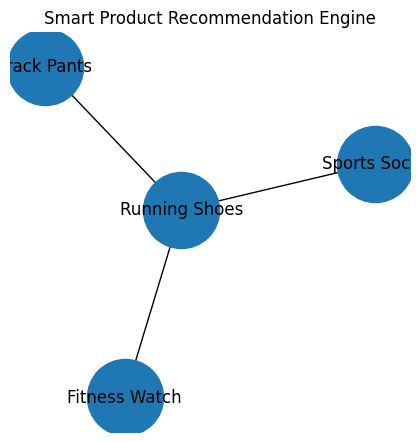

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

product = "Running Shoes"

recommendations = [
    "Sports Socks",
    "Fitness Watch",
    "Track Pants"
]

for item in recommendations:
    G.add_edge(product, item)

plt.figure(figsize=(4,4))
nx.draw(
    G,
    with_labels=True,
    node_size=3000
)

plt.title("Smart Product Recommendation Engine")
plt.show()


Task 2: Unique Product Catalog Creation

This task is actually asking:Can your AI detect duplicate or nearly identical products and keep only one copy?"

In [ ]:
df["product_text"] = (
    df["articleType"].astype(str) + " " +
    df["baseColour"].astype(str) + " " +
    df["gender"].astype(str) + " " +
    df["usage"].astype(str)
)

Generate Embeddings

Install:

pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = model.encode(
    df["product_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/1378 [00:00<?, ?it/s]

In [ ]:
embeddings

array([[-0.04369936,  0.01004265, -0.03343635, ...,  0.03622532,
         0.0339818 , -0.03551498],
       [-0.00935579,  0.01425781, -0.03218827, ...,  0.05882502,
         0.01590995, -0.03688725],
       [-0.02669195, -0.01787742, -0.08698296, ...,  0.00534174,
         0.05940051, -0.02201695],
       ...,
       [-0.03731897, -0.02220093,  0.00860031, ...,  0.02113527,
         0.02219643, -0.01680565],
       [-0.04029587,  0.00388058, -0.07439899, ...,  0.00400849,
         0.02226892, -0.03632303],
       [-0.07961604,  0.04690679, -0.0669267 , ..., -0.01052883,
         0.01037058,  0.0057376 ]], dtype=float32)

Find Similar Products

Use cosine similarity.
1.0 = identical
0.9 = very similar
0.2 = different

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    embeddings
)

In [ ]:
similarity_matrix

array([[1.0000004 , 0.7164937 , 0.6321734 , ..., 0.68279505, 0.47949827,
        0.5041821 ],
       [0.7164937 , 0.99999976, 0.7973326 , ..., 0.79595006, 0.65304184,
        0.66770923],
       [0.6321734 , 0.7973326 , 0.9999997 , ..., 0.76869416, 0.6801355 ,
        0.75126505],
       ...,
       [0.68279505, 0.79595006, 0.76869416, ..., 0.9999999 , 0.5497712 ,
        0.60086805],
       [0.47949827, 0.65304184, 0.6801355 , ..., 0.5497712 , 1.        ,
        0.67996335],
       [0.5041821 , 0.66770923, 0.75126505, ..., 0.60086805, 0.67996335,
        0.99999976]], dtype=float32)

: Cluster Similar Products

Install clustering.

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
clustering = DBSCAN(
    eps=0.15,
    min_samples=2,
    metric='cosine'
)

labels = clustering.fit_predict(
    embeddings
)

df["cluster"] = labels

In [ ]:
unique_catalog = (
    df.groupby("cluster")
      .first()
      .reset_index()
)

In [ ]:
unique_catalog[
    ["cluster","articleType","baseColour"]
]

,cluster,articleType,baseColour
0,-1,69,4
1,0,1,1
2,1,61,17
3,2,66,4
4,3,78,25
5,4,79,6
6,5,90,22
7,6,97,8
8,7,99,8
9,8,100,2


##### VISUALIZATION>>>

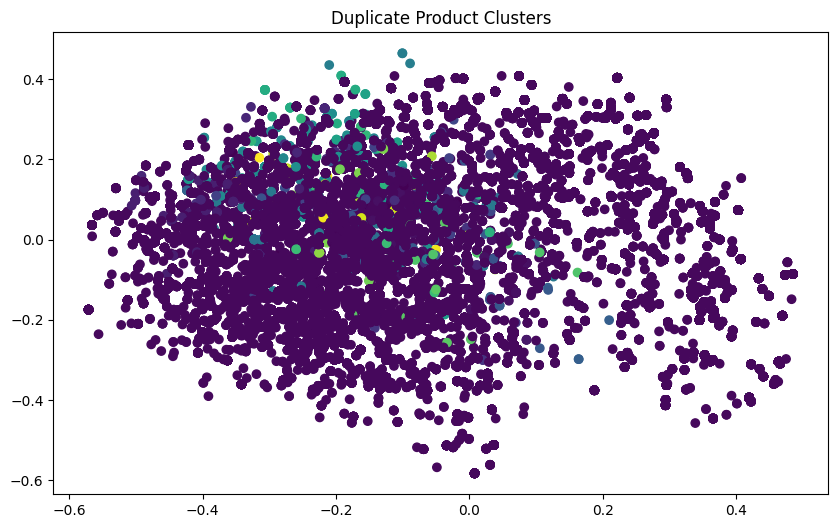

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

points = pca.fit_transform(
    embeddings
)

plt.figure(figsize=(10,6))

plt.scatter(
    points[:,0],
    points[:,1],
    c=labels
)

plt.title(
    "Duplicate Product Clusters"
)

plt.show()

In [ ]:
df['cluster'] = labels

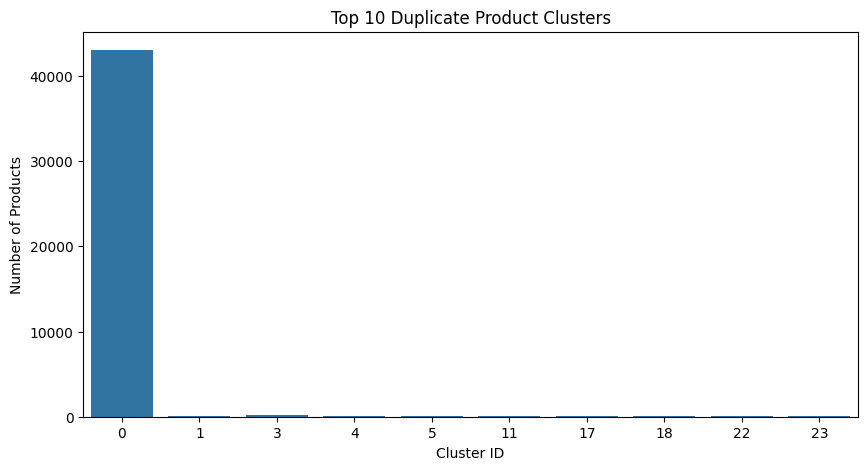

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_sizes = (
    df["cluster"]
    .value_counts()
    .head(10)
    .reset_index()
)

cluster_sizes.columns = [
    "Cluster",
    "Products"
]

plt.figure(figsize=(10,5))

sns.barplot(
    data=cluster_sizes,
    x="Cluster",
    y="Products"
)

plt.title(
    "Top 10 Duplicate Product Clusters"
)

plt.xlabel("Cluster ID")
plt.ylabel("Number of Products")

plt.show()